## 1. Import Required Libraries

Importing essential Python libraries for data manipulation and analysis.

In [1]:
# Import core libraries for data manipulation, numerical operations, and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load raw dataset from the data directory

df = pd.read_csv("../data/processed/route_efficiency_data.csv")

# Geographic Bottleneck Analysis

This section identifies geographic regions and states where shipping performance is inefficient.

Objectives:
- Detect states with the highest average lead time
- Identify high-volume states experiencing delays
- Analyze regional logistics performance

In [3]:
# State-Level Performance Aggregation

state_analysis = df.groupby('State/Province').agg(
    Total_Shipments=('Route', 'count'),
    Avg_Lead_Time=('lead_time', 'mean'),
    Lead_Time_Std=('lead_time', 'std'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Gross Profit', 'sum')
).reset_index()

In [4]:
state_analysis.head()

,State/Province,Total_Shipments,Avg_Lead_Time,Lead_Time_Std,Total_Sales,Total_Profit
0,Alabama,61,1291.278689,253.475320,995.11,622.11
1,Alberta,26,1274.076923,292.400673,530.32,326.30
2,Arizona,224,1309.214286,263.392440,3587.55,2290.11
3,Arkansas,60,1285.733333,284.746266,891.94,588.02
4,British Columbia,22,1290.318182,308.425091,290.90,198.30


## States with Highest Average Lead Time

These states represent potential logistics inefficiencies.

In [5]:
slow_states = state_analysis.sort_values(
    by='Avg_Lead_Time',
    ascending=False
)

In [6]:
slow_states.head()

,State/Province,Total_Shipments,Avg_Lead_Time,Lead_Time_Std,Total_Sales,Total_Profit
56,West Virginia,4,1638.000000,2.000000,63.97,43.89
37,North Dakota,7,1637.857143,1.463850,109.66,73.96
47,Saskatchewan,2,1457.000000,258.801082,29.25,18.99
20,Manitoba,12,1455.333333,191.139803,138.25,90.27
15,Iowa,30,1443.900000,229.801466,400.37,269.97


In [7]:
# Create bottleneck risk score

state_analysis['Risk_Score'] = (
    state_analysis['Avg_Lead_Time'] *
    state_analysis['Total_Shipments']
)

In [8]:
# Identify highest risk states

state_analysis.sort_values(
    by='Risk_Score',
    ascending=False
).head(10)

,State/Province,Total_Shipments,Avg_Lead_Time,Lead_Time_Std,Total_Sales,Total_Profit,Risk_Score
5,California,2001,1318.427286,264.392878,27917.40,18479.42,2638173.0
34,New York,1128,1324.493794,249.358503,15541.03,10222.44,1494029.0
51,Texas,985,1310.305584,266.727158,13416.09,8909.53,1290651.0
43,Pennsylvania,587,1324.199319,261.757227,8027.03,5225.47,777305.0
55,Washington,506,1360.662055,272.121963,6921.15,4566.64,688495.0
13,Illinois,492,1323.150407,269.717824,6898.96,4557.68,650990.0
39,Ohio,469,1325.733475,263.976639,6768.95,4413.03,621769.0
10,Florida,383,1311.396867,269.808259,4804.02,3207.11,502265.0
36,North Carolina,249,1334.883534,254.989434,3450.86,2331.16,332386.0
23,Michigan,255,1300.560784,244.054376,3331.00,2236.21,331643.0


## Regional Logistics Performance

Analyzing shipping efficiency across broader geographic regions.

In [9]:
region_analysis = df.groupby('Region').agg(
    Total_Shipments=('Route', 'count'),
    Avg_Lead_Time=('lead_time', 'mean'),
    Lead_Time_Std=('lead_time', 'std')
).reset_index()

In [10]:
region_analysis.sort_values(
    by='Avg_Lead_Time',
    ascending=False
)

,Region,Total_Shipments,Avg_Lead_Time,Lead_Time_Std
2,Interior,2335,1323.091221,262.693597
0,Atlantic,2986,1322.745144,256.541810
3,Pacific,3253,1322.194897,266.470647
1,Gulf,1620,1311.374691,264.727855


## Visualization of High Delay States

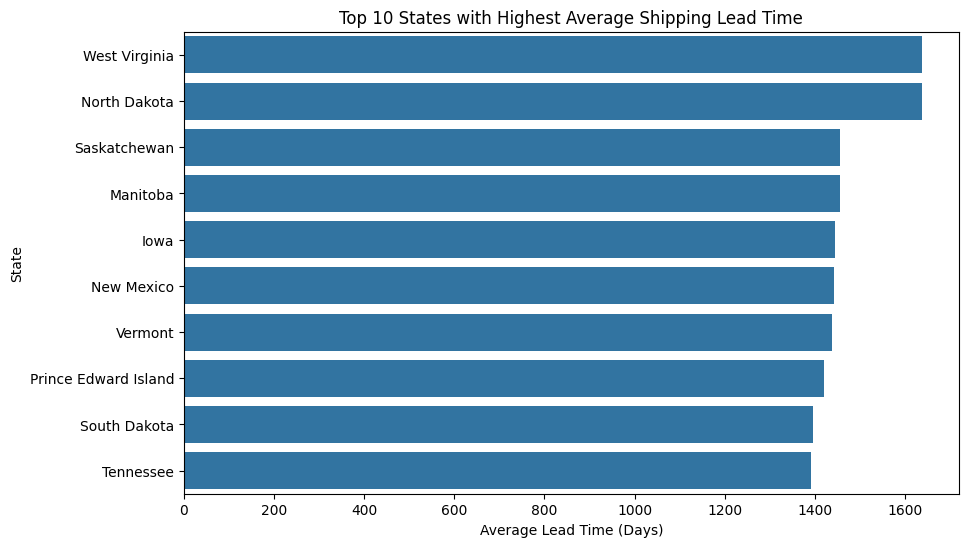

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=slow_states.head(10),
    x='Avg_Lead_Time',
    y='State/Province'
)

plt.title("Top 10 States with Highest Average Shipping Lead Time")
plt.xlabel("Average Lead Time (Days)")
plt.ylabel("State")

plt.show()

## Geographic Bottleneck Insights

Key findings from geographic analysis:

- Certain states experience significantly higher lead times.
- High shipment volume combined with high delays indicates operational bottlenecks.
- Regional patterns suggest potential distribution inefficiencies.

These insights help identify areas where logistics optimization efforts should be focused.

## Identifying Critical Geographic Bottlenecks

To prioritize operational improvements, we identify the states with the highest risk scores.  
The risk score combines shipment volume and lead time to highlight regions that may significantly impact logistics efficiency.

In [12]:
# Sort states based on Risk Score

critical_bottlenecks = state_analysis.sort_values(
    by="Risk_Score",
    ascending=False
)

In [13]:
critical_bottlenecks.head(10)

,State/Province,Total_Shipments,Avg_Lead_Time,Lead_Time_Std,Total_Sales,Total_Profit,Risk_Score
5,California,2001,1318.427286,264.392878,27917.40,18479.42,2638173.0
34,New York,1128,1324.493794,249.358503,15541.03,10222.44,1494029.0
51,Texas,985,1310.305584,266.727158,13416.09,8909.53,1290651.0
43,Pennsylvania,587,1324.199319,261.757227,8027.03,5225.47,777305.0
55,Washington,506,1360.662055,272.121963,6921.15,4566.64,688495.0
13,Illinois,492,1323.150407,269.717824,6898.96,4557.68,650990.0
39,Ohio,469,1325.733475,263.976639,6768.95,4413.03,621769.0
10,Florida,383,1311.396867,269.808259,4804.02,3207.11,502265.0
36,North Carolina,249,1334.883534,254.989434,3450.86,2331.16,332386.0
23,Michigan,255,1300.560784,244.054376,3331.00,2236.21,331643.0


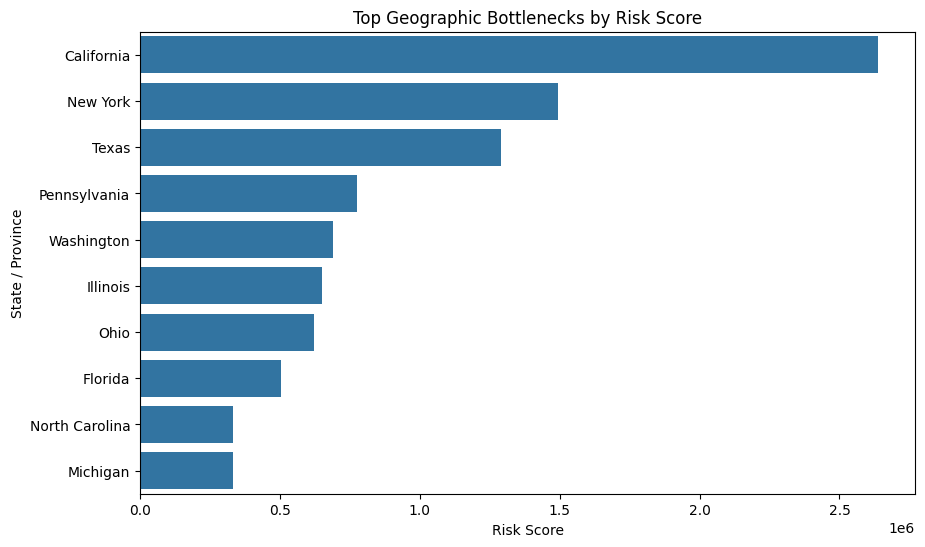

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=critical_bottlenecks.head(10),
    x="Risk_Score",
    y="State/Province"
)

plt.title("Top Geographic Bottlenecks by Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("State / Province")

plt.show()

## Key Insights

The geographic bottleneck analysis highlights several states with high shipment volumes and elevated lead times.

Key observations:

- Certain regions experience consistently higher logistics delays.
- High shipment concentration combined with longer lead times increases operational risk.
- These states represent potential logistics bottlenecks that may impact supply chain performance.

## Business Recommendations

- Optimize routing strategies for high-risk regions.
- Increase logistical resources or infrastructure support in bottleneck states.
- Monitor shipment lead times in these areas for early delay detection.

In [15]:
# Save geographic bottleneck analysis results

critical_bottlenecks.to_csv("../data/processed/geographic_bottleneck_analysis.csv", index=False)

## Conclusion

This analysis identified geographic regions that act as logistics bottlenecks based on shipment volume and lead time.  
These insights provide a foundation for optimizing shipping routes and improving supply chain efficiency.

The processed bottleneck dataset will support further analysis in subsequent stages of the project.